# 주차 공간 탐지 및 인식을 위한 객체 탐지 프로젝트 #3
**- 목표: 전체 train/val 데이터로 모델 재학습 및 평가**  
    (train 90 + val 10, 총 100장을 사용했을 때의 성능과 비교)

In [ ]:
# 구글 드라이브 마운트
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


전체 train/val set을 coco 포맷으로 통합

In [1]:
# 라벨 통합하는 코드
import os
import json
import cv2
import numpy as np

def calculate_area(polygon):
    x = np.array(polygon[::2])
    y = np.array(polygon[1::2])
    return 0.5 * np.abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))

def calculate_bbox(polygon):
    x = polygon[::2]
    y = polygon[1::2]
    return [min(x), min(y), max(x) - min(x), max(y) - min(y)]

def convert_to_coco(input_dir, output_file, directory):
    # 초기 세팅
    coco = {
        "images": [],
        "annotations": [],
        "categories": []
    }

    annotation_id = 0
    category_id_map = {}
    category_id_counter = 1

    # 라벨 변경
    for filename in os.listdir(input_dir):
        if filename.endswith('.json'):
            with open(os.path.join(input_dir, filename), 'r') as f:
                data = json.load(f)

                # 이미지 정보
                img_filename = filename.replace('.json', '.jpg')

                # img = cv2.imread('/content/drive/MyDrive/alice/dataset/' + directory + '/images/' + img_filename)
                # height, width, _ = img.shape

                image_info = {
                    "id": len(coco["images"]),
                    "file_name": img_filename, # 이미지와 라벨의 파일명은 같음
                    "width": 1920,
                    "height": 1080
                }
                coco["images"].append(image_info)

                '''
                # 2D bbox 어노테이션은 필요하면 추가
                for bbox2d in data.get("bbox2d", []):
                    category_name = bbox2d["name"]
                    if category_name not in category_id_map:
                        category_id_map[category_name] = category_id_counter
                        coco["categories"].append({
                            "id": category_id_counter,
                            "name": category_name
                        })
                        category_id_counter += 1

                    bbox = bbox2d["bbox"]
                    x_min, y_min, x_max, y_max = bbox
                    width = x_max - x_min
                    height = y_max - y_min

                    annotation = {
                        "id": annotation_id,
                        "image_id": image_info["id"],
                        "category_id": category_id_map[category_name],
                        "bbox": [x_min, y_min, width, height],
                        "area": width * height,
                        "iscrowd": 0
                    }
                    coco["annotations"].append(annotation)
                    annotation_id += 1
                '''

                # Add segmentations
                for segmentation in data.get("segmentation", []):
                    category_name = segmentation["name"]
                    if category_name not in category_id_map:
                        category_id_map[category_name] = category_id_counter
                        coco["categories"].append({
                            "id": category_id_counter,
                            "name": category_name
                        })
                        category_id_counter += 1

                    # segmentation을 [[x1, y1], [x1, y1], ...] => [x1, y1, x1, y1, ...] 형식으로 수정
                    new_seg = []
                    for x1, y1 in segmentation['polygon']:
                        new_seg.append(x1)
                        new_seg.append(y1)

                    # 면적 및 bbox 계산
                    area = calculate_area(new_seg)
                    bbox = calculate_bbox(new_seg)

                    annotation = {
                        "id": annotation_id,
                        "image_id": image_info["id"],
                        "category_id": category_id_map[category_name],
                        "segmentation": [new_seg],
                        "area": area,
                        "bbox": bbox,
                        "iscrowd": 0
                    }
                    coco["annotations"].append(annotation)
                    annotation_id += 1

    # Save the result to a JSON file
    with open(output_file, 'w') as f: # encoding='utf-8' 조건 추가 가능하지만 오래걸림
        json.dump(coco, f, indent=4) # ensure_ascii=False 조건을 추가하여 한글 깨짐을 해결할 수 있으나 시간 오래 걸림

In [2]:
for d in ('train', 'val'):
    print(f'{d} start')
    input_dir = 'dataset/' + d + '/labels'
    output_file = 'dataset/' + d + '.json'

    convert_to_coco(input_dir, output_file, d)

train start
val start


모델 학습 전 GPU 가용 상태 확인
- !nvidia-smi 시 GPU가 뜨지 않으면, 런타임 연결을 CPU에서 T4 GPU로 변경 후 코드 재실행

In [3]:
from tensorflow.python.client import device_lib
device_lib.list_local_devices()

2024-08-04 12:05:17.118319: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-08-04 12:05:17.127482: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-04 12:05:17.137449: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-04 12:05:17.140353: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-08-04 12:05:17.148298: I tensorflow/core/platform/cpu_feature_guar

[name: "/device:CPU:0"
 device_type: "CPU"
 memory_limit: 268435456
 locality {
 }
 incarnation: 6386590187537327434
 xla_global_id: -1]

In [4]:
!nvidia-smi

Sun Aug  4 12:05:18 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.27                 Driver Version: 560.70         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 980         On  |   00000000:01:00.0  On |                  N/A |
| 35%   49C    P2            172W /  390W |    2498MiB /   4096MiB |     91%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

필요한 라이브러리 import

In [6]:
# You may need to restart your runtime prior to this, to let your installation take effect
# Some basic setup
# Setup detectron2 logger
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# import some common libraries
import matplotlib.pyplot as plt
import numpy as np
import cv2

# import some common detectron2 utilities
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog

데이터셋 등록

In [7]:
from detectron2.data.datasets import register_coco_instances
register_coco_instances("train_parking", {}, "/content/drive/MyDrive/project/dataset/train.json", "/content/drive/MyDrive/project/dataset/train/images")
register_coco_instances("val_parking", {}, "/content/drive/MyDrive/project/dataset/val.json", "/content/drive/MyDrive/project/dataset/val/images")

val set에서 샘플 이미지 골라서 라벨 시각화

In [8]:
val_metadata = MetadataCatalog.get("val_parking")
dataset_dicts = DatasetCatalog.get("val_parking")

[08/04 12:06:26 d2.data.datasets.coco]: Loaded 787 images in COCO format from /content/drive/MyDrive/project/dataset/val.json


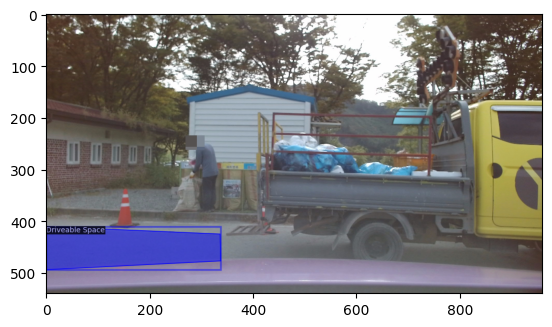

In [9]:
import random
import matplotlib.pyplot as plt

for d in random.sample(dataset_dicts, 3):
    img = cv2.imread(d["file_name"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    visualizer = Visualizer(img[:, :, ::-1], metadata=val_metadata, scale=0.5)
    vis = visualizer.draw_dataset_dict(d)    
    plt.imshow(vis.get_image()[:, :, ::-1])

In [10]:
from detectron2.engine import DefaultTrainer
from detectron2.config import get_cfg
from detectron2 import model_zoo
import os

cfg = get_cfg()
cfg.TRAIN_NAME = "train_all"
cfg.OUTPUT_DIR = os.path.join('./output', cfg.TRAIN_NAME)
cfg.merge_from_file("./detectron2_repo/configs/COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")
cfg.DATASETS.TRAIN = ("train_parking",) # 튜플 형태여야 하므로 콤마(,) 필수로 입력해야 함
cfg.DATASETS.TEST = ("val_parking",)   # 튜플 형태여야 하므로 콤마(,) 필수로 입력해야 함
cfg.DATALOADER.NUM_WORKERS = 2
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_101_FPN_3x.yaml") # initialize from model zoo
cfg.SOLVER.IMS_PER_BATCH = 2

num_gpu = 1
bs = (num_gpu * 2)
cfg.SOLVER.BASE_LR = 0.02 * bs / 16  # pick a good LR

cfg.TEST.EVAL_PERIOD = 100

cfg.SOLVER.MAX_ITER = 1000    # 데이터 수가 많으므로 시간이 너무 오래 걸리면 300 정도로 설정해서 학습
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128   # faster, and good enough for this toy dataset
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 3  # 3 classes

In [11]:
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()

[08/04 12:09:43 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

Skip loading parameter 'roi_heads.box_predictor.cls_score.weight' to the model due to incompatible shapes: (81, 1024) in the checkpoint but (4, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.cls_score.bias' to the model due to incompatible shapes: (81,) in the checkpoint but (4,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.weight' to the model due to incompatible shapes: (320, 1024) in the checkpoint but (12, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.bias' to the model due to incompatible shapes: (320,) in the checkpoint but (12,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.mask_head.predictor.weight' to the model due to incompatible shapes: (80, 256, 1, 1) in the checkpoint but (3, 256, 1, 1) 

[08/04 12:09:44 d2.engine.train_loop]: Starting training from iteration 0


/usr/local/lib/python3.10/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[08/04 12:09:59 d2.utils.events]:  eta: 0:10:59  iter: 19  total_loss: 3.402  loss_cls: 1.229  loss_box_reg: 0.3506  loss_mask: 0.6918  loss_rpn_cls: 0.7084  loss_rpn_loc: 0.3112    time: 0.6756  last_time: 0.6746  data_time: 0.0094  last_data_time: 0.0045   lr: 4.9952e-05  max_mem: 2581M
[08/04 12:10:12 d2.utils.events]:  eta: 0:10:51  iter: 39  total_loss: 2.432  loss_cls: 0.6843  loss_box_reg: 0.5202  loss_mask: 0.682  loss_rpn_cls: 0.1279  loss_rpn_loc: 0.3391    time: 0.6831  last_time: 0.6663  data_time: 0.0045  last_data_time: 0.0049   lr: 9.9902e-05  max_mem: 2581M
[08/04 12:10:26 d2.utils.events]:  eta: 0:10:56  iter: 59  total_loss: 2.29  loss_cls: 0.5374  loss_box_reg: 0.6664  loss_mask: 0.665  loss_rpn_cls: 0.1008  loss_rpn_loc: 0.3435    time: 0.6907  last_time: 0.7214  data_time: 0.0045  last_data_time: 0.0040   lr: 0.00014985  max_mem: 2581M
[08/04 12:10:40 d2.utils.events]:  eta: 0:10:46  iter: 79  total_loss: 2.216  loss_cls: 0.4863  loss_box_reg: 0.7231  loss_mask: 0.

## 3. 모델 평가

학습한 모델 load 및 threshold 값 설정
- threshold(임계값)는 0~1 사이이며, 값이 높을수록(1에 가까울수록) 명확한 대상만 검출

In [12]:
# Inference should use the config with parameters that are used in training
# cfg now already contains everything we've set previously. We changed it a little bit for inference:
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")  # path to the model we just trained
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.7   # set a custom testing threshold
predictor = DefaultPredictor(cfg)

[08/04 12:21:14 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./output/train_all/model_final.pth ...


/usr/local/lib/python3.10/site-packages/fvcore/common/checkpoint.py:252: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(f, map_location=torch.device("cpu"))

test dataset 등록 후 샘플 추론

In [13]:
from detectron2.data.datasets import register_coco_instances
register_coco_instances("test_parking", {}, "dataset/test.json", "dataset/test/images")

test_metadata = MetadataCatalog.get("test_parking")
dataset_dicts = DatasetCatalog.get("test_parking")

[08/04 12:21:14 d2.data.datasets.coco]: Loaded 788 images in COCO format from dataset/test.json


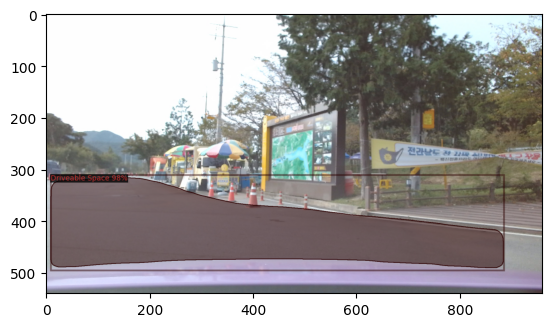

In [15]:
from detectron2.utils.visualizer import ColorMode
import matplotlib.pyplot as plt

for d in random.sample(dataset_dicts, 3):
    img = cv2.imread(d["file_name"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    outputs = predictor(img)  # format is documented at https://detectron2.readthedocs.io/tutorials/models.html#model-output-format
    v = Visualizer(img[:, :, ::-1],
                   metadata=val_metadata,
                   scale=0.5  # remove the colors osf unsegmented pixels. This option is only available for segmentation models
    )
    out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
    plt.imshow(out.get_image()[:, :, ::-1])

test set을 이용하여 모델 성능 평가
- AP(Average Precision): 객체 검출 시 사용하는 성능 지표
    - AP50: 임계값이 0.5일 때의 AP값
    - AP75: 임계값이 0.75일 때의 AP값
- AP 값이 높을수록 모델의 성능이 좋다는 것을 의미함

In [16]:
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader

evaluator = COCOEvaluator("test_parking", output_dir=os.path.join("./output/inference", cfg.TRAIN_NAME))
test_loader = build_detection_test_loader(cfg, "test_parking")
print(inference_on_dataset(predictor.model, test_loader, evaluator))

[08/04 12:21:47 d2.data.datasets.coco]: Loaded 788 images in COCO format from dataset/test.json
[08/04 12:21:47 d2.data.build]: Distribution of instances among all 2 categories:
|   category    | #instances   |   category    | #instances   |
|:-------------:|:-------------|:-------------:|:-------------|
| Driveable S.. | 991          | Parking Space | 3752         |
|               |              |               |              |
|     total     | 4743         |               |              |
[08/04 12:21:47 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[08/04 12:21:47 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[08/04 12:21:47 d2.data.common]: Serializing 788 elements to byte tensors and concatenating them all ...
[08/04 12:21:47 d2.data.common]: Serialized dataset takes 1.10 MiB
[08/04 12:21:47 d2.evaluation.eva